In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from datetime import date

**API call to get all Published Datasets**

In [2]:
api_url_base = 'https://api.cellxgene.cziscience.com'
path_segment = '/datasets'
url = f'{api_url_base}/curation/v1{path_segment}'
r = requests.get(url)
datasets = r.json()

**Extract necessary information, assign publication based on the earliest published date for each Collection**

In [3]:
datasets_df = pd.DataFrame(datasets)[['collection_id','primary_cell_count','published_at']]
datasets_df['published_at'] = pd.to_datetime(datasets_df['published_at']).dt.date

collection_earliest = datasets_df.groupby('collection_id')['published_at'].min().reset_index()
collection_earliest.columns = ['collection_id', 'earliest_date']

result = datasets_df.merge(collection_earliest, on='collection_id')
result = result.groupby('earliest_date').agg(
    collections=('collection_id', 'nunique'),
    primary_cells=('primary_cell_count', 'sum')
).reset_index()
result

,earliest_date,collections,primary_cells
0,2020-08-26,4,865124
1,2020-09-28,2,644647
2,2020-11-20,1,106136
3,2021-02-17,1,4837
4,2021-02-27,1,47019
...,...,...,...
286,2026-03-11,1,401253
287,2026-03-12,1,33932
288,2026-03-30,1,192634
289,2026-04-03,1,211970


**Extract citation stats for the CELLxGENE Discover publication**\
**Export CSV from [Dimensions](https://app.dimensions.ai/discover/publication?or_subset_publication_citations=pub.1182803254)**

In [4]:
dimensions_export = 'Dimensions-Publication-2026-04-01_19-17-52.csv.zip'

cited_by = pd.read_csv(dimensions_export, skiprows=1)[['Publication date']]
cited_by = cited_by['Publication date'].value_counts().to_frame().reset_index()
cited_by['Publication date'] = cited_by['Publication date'].apply(
    lambda x: x + '-01' if isinstance(x, str) and len(x) == 7 else x
)
cited_by['Publication date'] = pd.to_datetime(cited_by['Publication date']).dt.date
cited_by.rename(columns={'Publication date': 'earliest_date', 'count': 'cited_by'}, inplace=True)
cited_by

,earliest_date,cited_by
0,2025-11-26,5
1,2025-11-10,4
2,2026-01-09,4
3,2025-06-27,4
4,2025-04-16,4
...,...,...
254,2025-08-23,1
255,2025-08-22,1
256,2026-03-26,1
257,2026-02-18,1


**Calculate the relative date and running totals**

In [5]:
result = result.merge(cited_by, on='earliest_date', how='outer')
result.fillna(0, inplace=True)

min_date = result['earliest_date'].min()
result['yr_published'] = result['earliest_date'].apply(lambda x: (x - min_date).days / 365.25)

result = result.sort_values('yr_published').reset_index(drop=True)

result['cumsum_collections'] = result['collections'].cumsum()
result['cumsum_primary_cells'] = result['primary_cells'].cumsum().apply(lambda x: x/1000000)

result['cumsum_cited_by'] = result['cited_by'].cumsum()
result

,earliest_date,collections,primary_cells,cited_by,yr_published,cumsum_collections,cumsum_primary_cells,cumsum_cited_by
0,2020-08-26,4.0,865124.0,0.0,0.000000,4.0,0.865124,0.0
1,2020-09-28,2.0,644647.0,0.0,0.090349,6.0,1.509771,0.0
2,2020-11-20,1.0,106136.0,0.0,0.235455,7.0,1.615907,0.0
3,2021-02-17,1.0,4837.0,0.0,0.479124,8.0,1.620744,0.0
4,2021-02-27,1.0,47019.0,0.0,0.506502,9.0,1.667763,0.0
...,...,...,...,...,...,...,...,...
487,2026-03-26,0.0,0.0,1.0,5.579740,360.0,149.446656,351.0
488,2026-03-27,0.0,0.0,2.0,5.582478,360.0,149.446656,353.0
489,2026-03-30,1.0,192634.0,0.0,5.590691,361.0,149.639290,353.0
490,2026-04-03,1.0,211970.0,0.0,5.601643,362.0,149.851260,353.0


**View the current counts**

In [6]:
print(int(result['cumsum_collections'].max()), 'Collections')
print(round(result['cumsum_primary_cells'].max(),1), 'M cells')
print(int(result['cumsum_cited_by'].max()), 'Cited Bys')

364 Collections
150.1 M cells
353 Cited Bys


**Set the y-axis parameters based on current counts**

In [7]:
coll_max, coll_del_mj, coll_del_mi = 400, 100, 50
cell_max, cell_del_mj, cell_del_mi = 175, 50, 25
cite_max, cite_del_mj, cite_del_mi = 375, 100, 25

**Plot the Collection & Primary Cell Count growth**

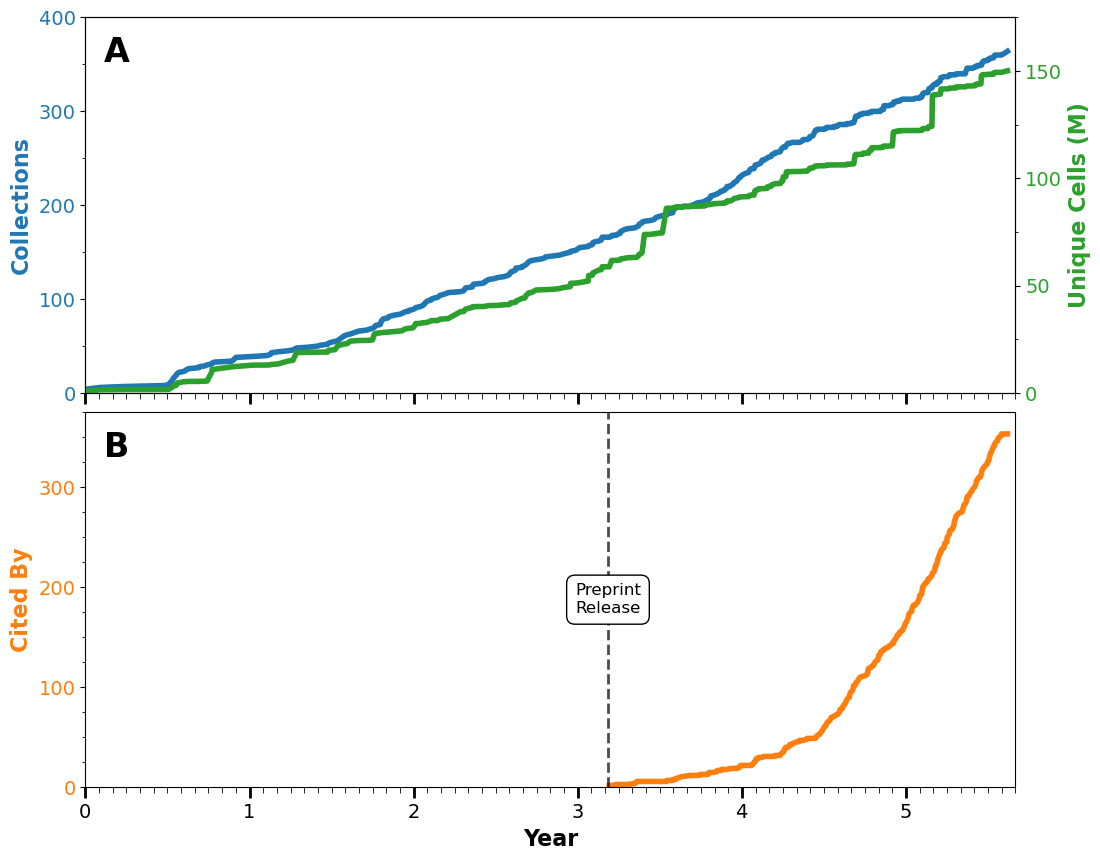

In [8]:
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), 
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05},
                                sharex=True)

# A: x-axis
yr_max = np.ceil(result['yr_published'].max() * 12) / 12
yr_del_mj, yr_del_mi = 1, 1/12
ax1.set_xlim(0, yr_max)
ax1.set_xticks(np.arange(0, yr_max, yr_del_mj), minor=False)
ax1.set_xticks(np.arange(0, yr_max, yr_del_mi), minor=True)
ax1.tick_params(axis='x', which='major', labelsize=14, labelbottom=False, length=8, width=2)
ax1.tick_params(axis='x', which='minor', length=4)

# A: left y-axis (collections)
color1 = 'tab:blue'
ax1.set_ylabel('Collections', color=color1, fontsize=16, fontweight='bold')
ax1.set_ylim(0, coll_max)
ax1.set_yticks(np.arange(0, coll_max + 0.1, coll_del_mj), minor=False)
ax1.set_yticks(np.arange(0, coll_max + 0.1, coll_del_mi), minor=True)
ax1.plot(result['yr_published'], result['cumsum_collections'], 
         color=color1, linewidth=4)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=14)

# A: right y-axis (cells)
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Unique Cells (M)', color=color2, fontsize=16, fontweight='bold')
ax2.set_ylim(0, cell_max)
ax2.set_yticks(np.arange(0, cell_max + 0.1, cell_del_mj), minor=False)
ax2.set_yticks(np.arange(0, cell_max + 0.1, cell_del_mi), minor=True)
ax2.plot(result['yr_published'], result['cumsum_primary_cells'], 
         color=color2, linewidth=4)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=14)

# B: x-axis
ax3.set_xlabel('Year', fontsize=16, fontweight='bold')
ax3.tick_params(axis='x', which='major', labelsize=14, length=8, width=2)
ax3.tick_params(axis='x', which='minor', length=4)

# B: left y-axis (cited by)
preprint_pub = date(2023, 11, 2)
cited_by_filtered = result[result['earliest_date'] >= preprint_pub]
preprint_yr = (preprint_pub - min_date).days / 365.25

color3 = 'tab:orange'
ax3.set_ylabel('Cited By', color=color3, fontsize=16, fontweight='bold')
ax3.set_ylim(0, cite_max)
ax3.set_yticks(np.arange(0, cite_max + 0.1, cite_del_mj), minor=False)
ax3.set_yticks(np.arange(0, cite_max + 0.1, cite_del_mi), minor=True)
ax3.plot(cited_by_filtered['yr_published'], cited_by_filtered['cumsum_cited_by'], 
         color=color3, linewidth=4)
ax3.tick_params(axis='y', labelcolor=color3, labelsize=14)

# B: vertical line for preprint release date
ax3.axvline(x=preprint_yr, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax3.text(preprint_yr, cite_max * 0.5, 'Preprint\nRelease', 
         ha='center', va='center', fontsize=12, color='black',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=1))

# Add labels A and B
ax1.text(0.02, 0.95, 'A', transform=ax1.transAxes, 
         fontsize=24, fontweight='bold', va='top', ha='left')
ax3.text(0.02, 0.95, 'B', transform=ax3.transAxes, 
         fontsize=24, fontweight='bold', va='top', ha='left')

plt.savefig('cxg_growth.png', dpi=300, bbox_inches='tight')
plt.show()